In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv("Overnight_MIBOR.csv")
data.head()

,Date,Overnight MIBOR(%),Rate_Decimal
0,01-Feb-24,6.85,0.0685
1,05-Feb-24,6.54,0.0654
2,06-Feb-24,6.55,0.0655
3,07-Feb-24,6.55,0.0655
4,08-Feb-24,6.75,0.0675


In [10]:
data.columns = data.columns.str.strip()
print(data.columns)
data.head()

Index(['Date', 'Overnight MIBOR(%)', 'Rate_Decimal'], dtype='object')


,Date,Overnight MIBOR(%),Rate_Decimal
0,01-Feb-24,6.85,0.0685
1,05-Feb-24,6.54,0.0654
2,06-Feb-24,6.55,0.0655
3,07-Feb-24,6.55,0.0655
4,08-Feb-24,6.75,0.0675


In [13]:
data["Date"] = pd.to_datetime(data["Date"],dayfirst=True)
data = data.sort_values("Date").reset_index(drop=True)
data.head()

C:\Users\Vivek\AppData\Local\Temp\ipykernel_20804\2889545164.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"],dayfirst=True)


,Date,Overnight MIBOR(%),Rate_Decimal
0,2024-02-01,6.85,0.0685
1,2024-02-05,6.54,0.0654
2,2024-02-06,6.55,0.0655
3,2024-02-07,6.55,0.0655
4,2024-02-08,6.75,0.0675


In [15]:
rates = data["Rate_Decimal"]
rates.head()

0    0.0685
1    0.0654
2    0.0655
3    0.0655
4    0.0675
Name: Rate_Decimal, dtype: float64

In [17]:
#plotting the historical MIBOR series

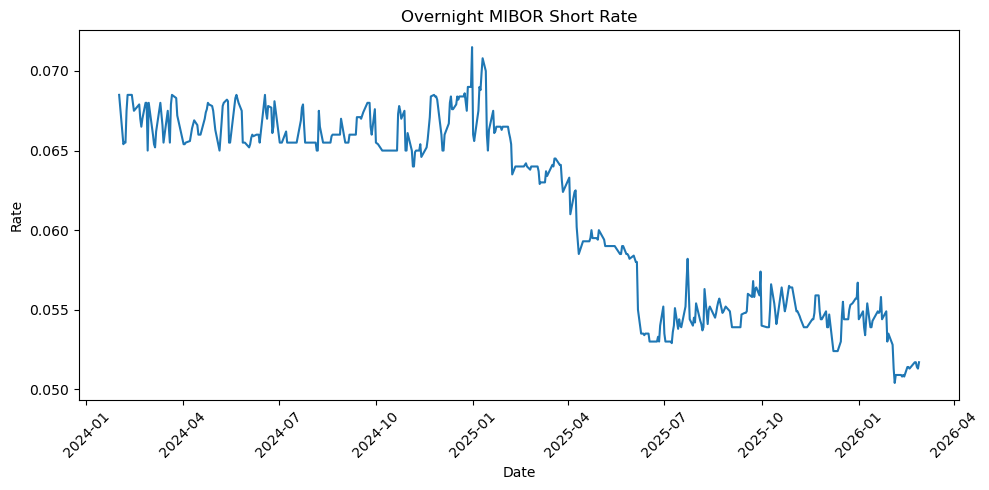

In [19]:
plt.figure(figsize=(10,5))
plt.plot(data["Date"],rates)
plt.title("Overnight MIBOR Short Rate")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Data for Vasicek estimation
# rt = today's rate
# rt+1 = next day's rate

In [21]:
data["r_t"] = data["Rate_Decimal"].shift(0)
data["r_t1"] = data["Rate_Decimal"].shift(-1)


In [25]:
Vasicek_data = data[["r_t","r_t1"]].dropna().copy()
Vasicek_data.head()

,r_t,r_t1
0,0.0685,0.0654
1,0.0654,0.0655
2,0.0655,0.0655
3,0.0655,0.0675
4,0.0675,0.0685


In [27]:
#Regression Coeffecients
#Rate for next period = Intercept + coeffecient * today's rate + Error term

In [29]:
x = Vasicek_data["r_t"].values
y = Vasicek_data["r_t1"].values

In [31]:
phi, c = np.polyfit(x, y, 1)
print("phi=", phi)
print("c=", c)

phi= 0.9882268750356628
c= 0.0006847659061065597


In [33]:
#Residuals = rt+1 - (c + slope * rt)
#sigma_hat = standard deviation of the residuals 


dt = 1/365
a = -np.log(phi)/dt
b = c / (1 - phi)
residuals = y - (c + phi * x)
sigma_hat = np.std(residuals, ddof = 1)
sigma = sigma_hat * np.sqrt((2 * a) / (1 - phi**2))
print("Estimated Vasicek Parameters:")
print("a =", a)
print("b =", b)
print("sigma =", sigma)

Estimated Vasicek Parameters:
a = 4.322686602241747
b = 0.058163478955742816
sigma = 0.018196406446542246


In [35]:
#The Vasicek model parameters estimated from the last two years of Overnight MIBOR data indicae a mean reversion speed of 4.323, a long run rate of 5.82% 
#and a volatility of 1.82%. The estimated persistence parameter of 0.98 suggests that in short term the rates are highly persistent and still exhibits a reversion behaviour.

In [89]:
#Estimate of short rate paths
no_steps = 365 * 6
no_sims = 1000
dt = 1/365
r0 = data["Rate_Decimal"].iloc[-1]
rates_sim = np.zeros((no_steps + 1, no_sims))
rates_sim[0, :] = r0
for t in range(1, no_steps + 1):
    z = np.random.normal(0, 1, no_sims)
    rates_sim[t, :] = rates_sim[t-1, :] + a * (b - rates_sim[t-1, :]) * dt +sigma * np.sqrt(dt) * z


In [91]:
rates_sim.shape

(2191, 1000)

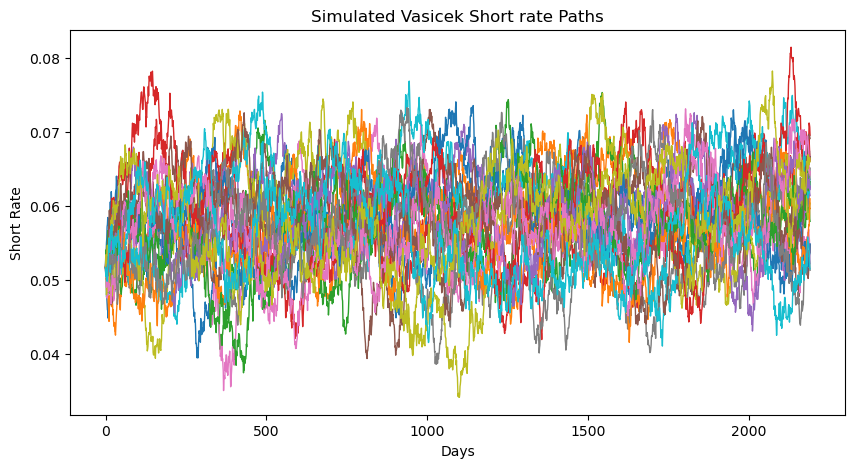

In [93]:
plt.figure(figsize=(10,5))
for i in range (20):
    plt.plot(rates_sim[:, i], linewidth=1)

plt.title("Simulated Vasicek Short rate Paths")
plt.xlabel("Days")
plt.ylabel("Short Rate")
plt.show()

In [42]:
r_3_5 = np.mean(rates_sim[int(3.5*365), :])
r_4_5 = np.mean(rates_sim[int(4.5*365), :])
r_5_5 = np.mean(rates_sim[int(5.5*365), :])

print("Expected 3.5 year rate:", r_3_5*100, "%")
print("Expected 4.5 year rate:", r_4_5*100, "%")
print("Expected 5.5 year rate:", r_5_5*100, "%")

Expected 3.5 year rate: 5.827383777713522 %
Expected 4.5 year rate: 5.871472890568289 %
Expected 5.5 year rate: 5.821159254442891 %


In [45]:
# Hull White Model
# dr(t) = [θ(t) + u(t) - a.r(t)]dt + σ1W1(t)
# here the long term mean changes with time

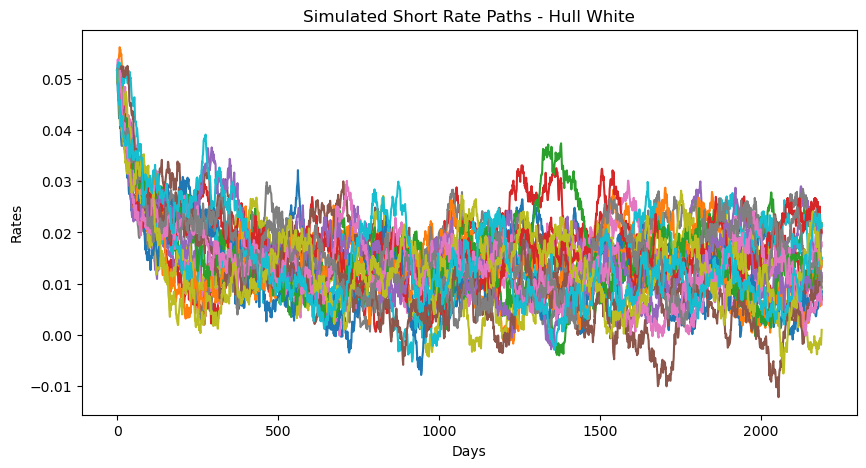

In [95]:
n_steps = 365 * 6
n_sims = 1000
dt = 1/365
rates_hullwhite = np.zeros((n_steps + 1, n_sims))
rates_hullwhite[0, :] = r0

for t in range (1, n_steps + 1):
    z = np.random.normal(0,1, n_sims)
    theta = b
    rates_hullwhite[t, :] = rates_hullwhite[t-1, :] + (theta - a * rates_hullwhite[t-1, :]) * dt + sigma * np.sqrt(dt)*z
plt.figure(figsize=(10,5))
plt.plot(rates_hullwhite[:, :20])
plt.title("Simulated Short Rate Paths - Hull White")
plt.xlabel("Days")
plt.ylabel("Rates")
plt.show()

In [61]:
hullwhite_3_5 = rates_hullwhite[int(3.5*365), :].mean()
hullwhite_4_5 = rates_hullwhite[int(4.5*365), :].mean()
hullwhite_5_5 = rates_hullwhite[int(5.5*365), :].mean()
print(hullwhite_3_5*100, "%")
print(hullwhite_4_5*100, "%")
print(hullwhite_5_5*100, "%")

1.338410435618599 %
1.324091941531497 %
1.3307126586814135 %


In [73]:
comparison = pd.DataFrame({"Model":["Vasicek", "Hull-White"],
                           "3.5Y Rate (%)": [r_3_5 * 100, hullwhite_3_5 * 100],
                           "4.5Y Rate (%)": [r_4_5 * 100, hullwhite_4_5 * 100],
                           "5.5Y Rate (%)": [r_5_5 * 100, hullwhite_5_5 * 100]})
comparison = comparison.round(2)
comparison 

,Model,3.5Y Rate (%),4.5Y Rate (%),5.5Y Rate (%)
0,Vasicek,5.83,5.87,5.82
1,Hull-White,1.34,1.32,1.33
